In [25]:
# CELL 1 IMPORT + SETUP


import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        10,
})

IS_START  = '2018-01-01'
IS_END    = '2022-12-31'
OOS_START = '2023-01-01'
OOS_END   = '2025-12-31'

print('Setup complete ✓')

Setup complete ✓


In [26]:
#  CELL 2 DATA DOWNLOAD
TICKERS = [
    'GLD', 'SPY', 'QQQ', 'TQQQ',
    'BTC-USD', 'SOL-USD', 'ETH-USD', 'BNB-USD',
    'MSFT', 'AAPL', 'NVDA', 'GDX', 'SMH'
]

raw = yf.download(TICKERS, start='2018-01-01', end=OOS_END, auto_adjust=True)

price_data = {}
for ticker in TICKERS:
    try:
        df = pd.DataFrame({
            'Open':   raw['Open'][ticker],
            'High':   raw['High'][ticker],
            'Low':    raw['Low'][ticker],
            'Close':  raw['Close'][ticker],
            'Volume': raw['Volume'][ticker],
        }).dropna()
        price_data[ticker] = df
        print(f'  {ticker}: {len(df)} bars  ({df.index[0].date()} → {df.index[-1].date()})')
    except Exception as e:
        print(f'  {ticker}: FAILED — {e}')

print(f'\nLoaded {len(price_data)} tickers ✓')

[*********************100%***********************]  13 of 13 completed

  GLD: 2010 bars  (2018-01-02 → 2025-12-30)
  SPY: 2010 bars  (2018-01-02 → 2025-12-30)
  QQQ: 2010 bars  (2018-01-02 → 2025-12-30)
  TQQQ: 2010 bars  (2018-01-02 → 2025-12-30)
  BTC-USD: 2921 bars  (2018-01-01 → 2025-12-30)
  SOL-USD: 2091 bars  (2020-04-10 → 2025-12-30)
  ETH-USD: 2921 bars  (2018-01-01 → 2025-12-30)
  BNB-USD: 2921 bars  (2018-01-01 → 2025-12-30)
  MSFT: 2010 bars  (2018-01-02 → 2025-12-30)
  AAPL: 2010 bars  (2018-01-02 → 2025-12-30)
  NVDA: 2010 bars  (2018-01-02 → 2025-12-30)
  GDX: 2010 bars  (2018-01-02 → 2025-12-30)
  SMH: 2010 bars  (2018-01-02 → 2025-12-30)

Loaded 13 tickers ✓


In [27]:
# ── SuperTrend ────────────────────────────────────────────────────────────────
def compute_atr(high, low, close, period):
    prev_close = close.shift(1)
    tr = pd.concat([
        high - low,
        (high - prev_close).abs(),
        (low  - prev_close).abs(),
    ], axis=1).max(axis=1)
    atr = np.full(len(tr), np.nan)
    atr[period - 1] = tr.iloc[:period].mean()
    alpha = 1.0 / period
    for i in range(period, len(tr)):
        atr[i] = atr[i-1] * (1 - alpha) + tr.iloc[i] * alpha
    return pd.Series(atr, index=close.index)


def supertrend_signal(high, low, close, atr_period, multiplier):
    """
    Returns 0/1 Series.
    Signal is set on bar i using direction[i-1] — no shift needed in compute_metrics.
    compute_metrics will NOT shift this signal again (see Cell 6).
    """
    hl2 = (high + low) / 2.0
    atr = compute_atr(high, low, close, atr_period)
    basic_upper = hl2 + multiplier * atr
    basic_lower = hl2 - multiplier * atr

    n  = len(close)
    fu = np.full(n, np.nan)
    fl = np.full(n, np.nan)
    direction = np.full(n, np.nan)

    c  = close.values
    bu = basic_upper.values
    bl = basic_lower.values

    seed = atr_period
    fu[seed] = bu[seed]
    fl[seed] = bl[seed]
    direction[seed] = 1 if c[seed] > bu[seed] else -1

    for i in range(seed + 1, n):
        if np.isnan(bu[i]):
            continue
        fu[i] = bu[i] if (bu[i] < fu[i-1] or c[i-1] > fu[i-1]) else fu[i-1]
        fl[i] = bl[i] if (bl[i] > fl[i-1] or c[i-1] < fl[i-1]) else fl[i-1]
        if   c[i] > fu[i-1]: direction[i] =  1
        elif c[i] < fl[i-1]: direction[i] = -1
        else:                 direction[i] = direction[i-1]

    dir_s = pd.Series(direction, index=close.index)
    # shift(1): today's position is based on yesterday's direction
    # This is the ONE shift — compute_metrics must NOT shift again
    signal = (dir_s.shift(1) == 1).astype(float).fillna(0).astype(int)
    return signal


# ── KAMA ──────────────────────────────────────────────────────────────────────
def kama_signal(close, er_period, fast_period, slow_period):
    """
    State machine uses iloc[i-1] thresholds internally.
    Position at bar i reflects signal from bar i-1. No further shift needed.
    """
    fast_sc = 2 / (fast_period + 1)
    slow_sc = 2 / (slow_period + 1)
    c = close.values
    n = len(c)
    kama = np.full(n, np.nan)
    kama[er_period - 1] = c[er_period - 1]
    for i in range(er_period, n):
        direction  = abs(c[i] - c[i - er_period])
        volatility = np.sum(np.abs(np.diff(c[i - er_period: i + 1])))
        er = direction / volatility if volatility != 0 else 0
        sc = (er * (fast_sc - slow_sc) + slow_sc) ** 2
        kama[i] = kama[i-1] + sc * (c[i] - kama[i-1])
    kama_s = pd.Series(kama, index=close.index)

    position = pd.Series(0, index=close.index, dtype=int)
    state = 0
    for i in range(1, n):
        if pd.isna(kama_s.iloc[i-1]):
            continue
        if state == 0:
            if close.iloc[i] > kama_s.iloc[i-1]: state = 1
        else:
            if close.iloc[i] < kama_s.iloc[i-1]: state = 0
        position.iloc[i] = state
    return position


# ── RSI Rolling Window ────────────────────────────────────────────────────────
def rsi_window_signal(close, rsi_period, window):
    """
    State machine uses iloc[i-1] thresholds. No further shift needed.
    """
    delta    = close.diff()
    gain     = delta.clip(lower=0)
    loss     = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/rsi_period, min_periods=rsi_period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/rsi_period, min_periods=rsi_period, adjust=False).mean()
    rs       = avg_gain / avg_loss.replace(0, np.nan)
    rsi      = 100 - (100 / (1 + rs))
    upper    = rsi.rolling(window).quantile(0.80)
    lower    = rsi.rolling(window).quantile(0.20)

    position = pd.Series(0, index=close.index, dtype=int)
    state = 0
    for i in range(1, len(rsi)):
        up = upper.iloc[i-1]
        lo = lower.iloc[i-1]
        if pd.isna(up) or pd.isna(lo):
            position.iloc[i] = state
            continue
        if state == 0:
            if rsi.iloc[i] > up: state = 1
        else:
            if rsi.iloc[i] < lo: state = 0
        position.iloc[i] = state
    return position


# ── Triple EMA ────────────────────────────────────────────────────────────────
def triple_ema_signal(close, fast, medium, slow):
    """
    Bullish when Fast > Medium > Slow on previous bar.
    Shift(1) here = today's position based on yesterday's alignment.
    compute_metrics must NOT shift again.
    """
    ef = close.ewm(span=fast,   adjust=False).mean()
    em = close.ewm(span=medium, adjust=False).mean()
    es = close.ewm(span=slow,   adjust=False).mean()
    bullish = ((ef > em) & (em > es)).astype(int)
    return bullish.shift(1).fillna(0).astype(int)


# ── MACD ──────────────────────────────────────────────────────────────────────
def macd_signal(close, fast, slow, signal):
    """
    Bullish when MACD > Signal on previous bar.
    Shift(1) here. compute_metrics must NOT shift again.
    """
    ema_fast    = close.ewm(span=fast,   adjust=False).mean()
    ema_slow    = close.ewm(span=slow,   adjust=False).mean()
    macd_line   = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    bullish = (macd_line > signal_line).astype(int)
    return bullish.shift(1).fillna(0).astype(int)


# ── Donchian Channel ──────────────────────────────────────────────────────────
def donchian_signal(close, high, low, entry_period, exit_period):
    """
    State machine uses iloc[i-1] bands. No further shift needed.
    """
    upper_entry = high.rolling(entry_period).max()
    lower_exit  = low.rolling(exit_period).min()

    position = pd.Series(0, index=close.index, dtype=int)
    state = 0
    for i in range(1, len(close)):
        if state == 0:
            if close.iloc[i] > upper_entry.iloc[i-1]: state = 1
        else:
            if close.iloc[i] < lower_exit.iloc[i-1]:  state = 0
        position.iloc[i] = state
    return position


# ── Bollinger Bands ───────────────────────────────────────────────────────────
def bollinger_signal(close, period, mult):
    """
    State machine checks cross on bars i-1 → i. No further shift needed.
    """
    middle = close.rolling(window=period).mean()
    std    = close.rolling(window=period).std(ddof=0)
    lower  = middle - mult * std

    position = pd.Series(0, index=close.index, dtype=int)
    state = 0
    for i in range(1, len(close)):
        if pd.isna(lower.iloc[i-1]):
            continue
        if state == 0:
            if close.iloc[i-1] > lower.iloc[i-1] and close.iloc[i] <= lower.iloc[i]:
                state = 1
        else:
            if close.iloc[i-1] < middle.iloc[i-1] and close.iloc[i] >= middle.iloc[i]:
                state = 0
        position.iloc[i] = state
    return position


print('Indicator library defined ✓')

Indicator library defined ✓


In [28]:
# CELL 4 SIGNAL CONFIGURATIONS

def build_signals(ticker, df):
    """Returns {label: signal_series} for a given ticker using optimised params."""
    c, h, l = df['Close'], df['High'], df['Low']

    configs = {
        'GLD': [
            ('MACD(75,226,150)',  lambda: macd_signal(c, 75, 226, 150)),
            ('3EMA(56,91,116)',   lambda: triple_ema_signal(c, 56, 91, 116)),
            ('KAMA(49,10,55)',    lambda: kama_signal(c, 49, 10, 55)),
        ],
        'SPY': [
            ('3EMA(6,11,26)',     lambda: triple_ema_signal(c, 6, 11, 26)),
            ('KAMA(29,2,15)',     lambda: kama_signal(c, 29, 2, 15)),
        ],
        'QQQ': [
            ('MACD(190,266,190)', lambda: macd_signal(c, 190, 266, 190)),
            ('ST(22,1.5)',        lambda: supertrend_signal(h, l, c, 22, 1.5)),
            ('KAMA(43,10,20)',    lambda: kama_signal(c, 43, 10, 20)),
        ],
        'TQQQ': [
            ('ST(26,2.5)',        lambda: supertrend_signal(h, l, c, 26, 2.5)),
        ],
        'BTC-USD': [
            ('RSI_W(5,165)',      lambda: rsi_window_signal(c, 5, 165)),
            ('KAMA(7,10,20)',     lambda: kama_signal(c, 7, 10, 20)),
        ],
        'SOL-USD': [
            ('RSI_W(28,35)',      lambda: rsi_window_signal(c, 28, 35)),
            ('MACD(10,21,50)',    lambda: macd_signal(c, 10, 21, 50)),
        ],
        'ETH-USD': [
            ('3EMA(6,11,21)',     lambda: triple_ema_signal(c, 6, 11, 21)),
            ('RSI_W(10,65)',      lambda: rsi_window_signal(c, 10, 65)),
        ],
        'MSFT': [
            ('ST(24,6.0)',        lambda: supertrend_signal(h, l, c, 24, 6.0)),
            ('KAMA(57,4,60)',     lambda: kama_signal(c, 57, 4, 60)),
        ],
        'AAPL': [
            ('BB(45,0.5)',        lambda: bollinger_signal(c, 45, 0.5)),
            ('ST(10,2.0)',        lambda: supertrend_signal(h, l, c, 10, 2.0)),
            ('KAMA(27,2,60)',     lambda: kama_signal(c, 27, 2, 60)),
        ],
        'BNB-USD': [
            ('MACD(5,6,5)',       lambda: macd_signal(c, 5, 6, 5)),
            ('DON(30,17)',        lambda: donchian_signal(c, h, l, 30, 17)),
            ('ST(8,4.0)',         lambda: supertrend_signal(h, l, c, 8, 4.0)),
        ],
        'NVDA': [
            ('3EMA(46,61,146)',   lambda: triple_ema_signal(c, 46, 61, 146)),
            ('MACD(210,241,195)',  lambda: macd_signal(c, 210, 241, 195)),
        ],
        'GDX': [
            ('ST(23,4.5)',        lambda: supertrend_signal(h, l, c, 23, 4.5)),
        ],
        'SMH': [
            ('KAMA(27,16,25)',    lambda: kama_signal(c, 27, 16, 25)),
            ('3EMA(86,121,206)',  lambda: triple_ema_signal(c, 86, 121, 206)),
            ('MACD(17,261,255)',  lambda: macd_signal(c, 17, 261, 255)),
        ],
    }

    if ticker not in configs:
        return {}

    signals = {}
    for label, fn in configs[ticker]:
        try:
            signals[label] = fn()
        except Exception as e:
            print(f'  Warning: {ticker} {label} failed — {e}')
    return signals


print('Signal configs defined ✓')

Signal configs defined ✓


In [29]:
# CELL 5 ENSEMBLE ENGINE

# Logic modes: AND / OR / MAJORITY
# MAJORITY degrades to OR for 2-indicator ensembles (1 of 2 = 50%)
#
# Exit logic operates on INVERTED signals:
#   OR  exit → any indicator flipping to 0 triggers exit  (fast)
#   AND exit → all indicators must be 0 to exit           (slow)
#   MAJ exit → majority must be 0 to exit

def apply_logic(signals_arr, mode):
    n = len(signals_arr)
    if mode == 'AND':
        return all(s == 1 for s in signals_arr)
    elif mode == 'OR':
        return any(s == 1 for s in signals_arr)
    elif mode == 'MAJORITY':
        if n <= 2:
            return any(s == 1 for s in signals_arr)  # OR for 2-ind
        return sum(s == 1 for s in signals_arr) > n / 2
    return False


def run_ensemble(signal_dict, entry_logic, exit_logic):
    """
    Combine signals with independent entry/exit logic.
    Returns a 0/1 position Series.
    """
    labels = list(signal_dict.keys())
    n_ind  = len(labels)

    if n_ind == 0:
        raise ValueError('No signals provided')
    if n_ind == 1:
        # Single indicator — return as-is, logic irrelevant
        return list(signal_dict.values())[0]

    sig_df = pd.DataFrame(signal_dict).fillna(0).astype(int)
    pos    = pd.Series(0, index=sig_df.index, dtype=int)
    state  = 0

    for i in range(1, len(sig_df)):
        row = sig_df.iloc[i].values

        if state == 0:
            # Entry: how many indicators are ON?
            if apply_logic(row, entry_logic):
                state = 1
        else:
            # Exit: invert signals (1 = wants out), check exit condition
            exit_row = [1 - s for s in row]
            if apply_logic(exit_row, exit_logic):
                state = 0

        pos.iloc[i] = state

    return pos


print('Ensemble engine defined ✓')

Ensemble engine defined ✓


In [30]:
# Crypto tickers need 365-day annualisation
CRYPTO_TICKERS = {'BTC-USD', 'ETH-USD', 'SOL-USD', 'BNB-USD'}

# Transaction cost in basis points (one-way). 10bps = 0.10% per trade side.
# Round-trip cost applied on every entry and every exit.
TRANSACTION_COST_BPS = 10   # ← adjust as needed


def get_periods(ticker):
    """365 for crypto, 252 for everything else."""
    return 365 if ticker in CRYPTO_TICKERS else 252


def sharpe_ratio(returns, periods=252, rf=0.04, position=None):
    """
    Annualised Sharpe ratio.

    Key fix: when position=0 the strategy earns 0, not -rf/252.
    We only subtract the risk-free rate on bars where we are actually invested,
    so flat periods don't drag down Sharpe vs always-on strategies.
    """
    clean_ret = returns.dropna()
    if len(clean_ret) == 0 or clean_ret.std() == 0:
        return np.nan

    if position is not None:
        # Only charge rf on invested bars
        pos_aligned = position.reindex(clean_ret.index).fillna(0).shift(1).fillna(0)
        daily_rf    = (rf / periods) * pos_aligned
    else:
        daily_rf = rf / periods

    excess = clean_ret - daily_rf
    return (excess.mean() / excess.std()) * np.sqrt(periods)


def total_return(equity):
    eq = equity.dropna()
    return eq.iloc[-1] / eq.iloc[0] - 1 if len(eq) > 0 else np.nan


def max_drawdown(equity):
    eq = equity.dropna()
    return ((eq - eq.cummax()) / eq.cummax()).min()


def trade_count(position):
    return int((position.diff() == 1).sum())


def avg_trade_duration(position):
    entry_idx = position.index[position.diff() == 1].tolist()
    exit_idx  = position.index[position.diff() == -1].tolist()
    if not entry_idx:
        return np.nan
    durations = []
    for en in entry_idx:
        later = [ex for ex in exit_idx if ex > en]
        if later:
            durations.append((later[0] - en).days)
    return round(np.mean(durations), 1) if durations else np.nan


def apply_transaction_costs(strat_ret, position, cost_bps=TRANSACTION_COST_BPS):
    """
    Deduct cost_bps (one-way) on every entry and every exit.
    Round-trip = 2 × cost_bps per trade.
    """
    cost_pct  = cost_bps / 10_000
    trades    = position.diff().abs()   # 1 on both entry and exit bars
    costs     = trades * cost_pct
    return strat_ret - costs


def compute_metrics(position, close, label='', ticker=''):
    """
    position : 0/1 Series — already correctly shifted by the indicator functions.
               compute_metrics does NOT apply an additional shift here.
    """
    periods   = get_periods(ticker)
    daily_ret = close.pct_change()

    # No extra shift — indicators handle their own look-ahead prevention
    strat_ret = daily_ret * position

    # Apply transaction costs
    strat_ret = apply_transaction_costs(strat_ret, position)

    equity    = (1 + strat_ret).cumprod()
    bnh_eq    = (1 + daily_ret).cumprod()

    n_trades  = trade_count(position)
    years     = len(close) / periods
    tpy       = round(n_trades / years, 1) if years > 0 else np.nan

    return {
        'label':         label,
        'total_return':  total_return(equity),
        'sharpe':        sharpe_ratio(strat_ret, periods=periods,
                                      position=position),
        'max_dd':        max_drawdown(equity),
        'trades':        n_trades,
        'trades_per_yr': tpy,
        'avg_dur_days':  avg_trade_duration(position),
        'bnh_return':    total_return(bnh_eq),
        'equity':        equity,
        'strat_ret':     strat_ret,
        'position':      position,
    }


print('Metrics defined ✓')


Metrics defined ✓


In [31]:
# BACKTEST RUNNER

LOGIC_MODES = ['AND', 'OR', 'MAJORITY']
MIN_TRADES_PER_YEAR = 2


def run_ticker(ticker, entry_logic='AND', exit_logic='OR', verbose=True):
    if ticker not in price_data:
        print(f'{ticker}: no data')
        return None

    df      = price_data[ticker]
    signals = build_signals(ticker, df)
    n_ind   = len(signals)

    if n_ind == 0:
        print(f'{ticker}: no signals built')
        return None

    position_full = run_ensemble(signals, entry_logic, exit_logic)

    is_mask   = (df.index >= IS_START)  & (df.index <= IS_END)
    oos_mask  = (df.index >= OOS_START) & (df.index <= OOS_END)
    full_mask = (df.index >= IS_START)  & (df.index <= OOS_END)

    is_m   = compute_metrics(position_full[is_mask],   df['Close'][is_mask],
                              label=f'{ticker} IS',   ticker=ticker)
    oos_m  = compute_metrics(position_full[oos_mask],  df['Close'][oos_mask],
                              label=f'{ticker} OOS',  ticker=ticker)
    full_m = compute_metrics(position_full[full_mask], df['Close'][full_mask],
                              label=f'{ticker} FULL', ticker=ticker)

    if verbose:
        is_ok  = is_m['trades_per_yr']  is not None and is_m['trades_per_yr']  >= MIN_TRADES_PER_YEAR
        oos_ok = oos_m['trades_per_yr'] is not None and oos_m['trades_per_yr'] >= MIN_TRADES_PER_YEAR
        flag   = '' if (is_ok and oos_ok) else '  ⚠ FILTERED (< 2 trades/yr)'
        print(f'  {ticker} | Entry:{entry_logic} Exit:{exit_logic} | '
              f'Full Sharpe:{full_m["sharpe"]:.2f} | '
              f'IS Sharpe:{is_m["sharpe"]:.2f}  OOS Sharpe:{oos_m["sharpe"]:.2f} | '
              f'IS DD:{is_m["max_dd"]:.1%}  OOS DD:{oos_m["max_dd"]:.1%} | '
              f'Trades/yr IS:{is_m["trades_per_yr"]}  OOS:{oos_m["trades_per_yr"]}{flag}')

    return {
        'ticker':       ticker,
        'n_indicators': n_ind,
        'entry_logic':  entry_logic,
        'exit_logic':   exit_logic,
        'is':           is_m,
        'oos':          oos_m,
        'full':         full_m,
        'signals':      signals,
        'position':     position_full,
        'close':        df['Close'],
    }


def passes_min_trades(r):
    """Must meet minimum trades/yr in both IS and OOS."""
    is_tpy  = r['is']['trades_per_yr']
    oos_tpy = r['oos']['trades_per_yr']
    if is_tpy  is None or np.isnan(is_tpy)  or is_tpy  < MIN_TRADES_PER_YEAR:
        return False
    if oos_tpy is None or np.isnan(oos_tpy) or oos_tpy < MIN_TRADES_PER_YEAR:
        return False
    return True


def run_all_combos(ticker):
    """
    Run all 9 entry/exit combinations.

    Selection metric: full-period Sharpe (IS + OOS concatenated).
    IS/OOS split is shown as a diagnostic only — not used for selection.
    Combos with < MIN_TRADES_PER_YEAR in either period are excluded.
    """
    rows, results, filtered = [], {}, []

    for entry in LOGIC_MODES:
        for exit_ in LOGIC_MODES:
            key = f'{entry}/{exit_}'
            r   = run_ticker(ticker, entry, exit_, verbose=False)
            if r is None:
                continue

            if not passes_min_trades(r):
                filtered.append(
                    f'{key}  '
                    f'(IS:{r["is"]["trades_per_yr"]} OOS:{r["oos"]["trades_per_yr"]} trades/yr)'
                )
                continue

            results[key] = r
            rows.append({
                'Entry':          entry,
                'Exit':           exit_,
                # ── Selection metric (rank by this) ──
                'Full Sharpe':    r['full']['sharpe'],
                'Full Return':    r['full']['total_return'],
                'Full Max DD':    r['full']['max_dd'],
                # ── Diagnostic split ──
                'IS Sharpe':      r['is']['sharpe'],
                'IS Max DD':      r['is']['max_dd'],
                'IS Trades/yr':   r['is']['trades_per_yr'],
                'OOS Sharpe':     r['oos']['sharpe'],
                'OOS Max DD':     r['oos']['max_dd'],
                'OOS Trades/yr':  r['oos']['trades_per_yr'],
                # ── Decay: how much did it degrade OOS ──
                'Sharpe Decay':   r['is']['sharpe'] - r['oos']['sharpe'],
            })

    if filtered:
        print(f'  ⚠  {ticker}: {len(filtered)} combo(s) filtered '
              f'(< {MIN_TRADES_PER_YEAR} trades/yr):')
        for f in filtered:
            print(f'      {f}')

    if not rows:
        print(f'  ✗  {ticker}: NO valid combinations passed the minimum trades filter.')
        return None, None

    # ── Sort by full-period Sharpe — this is the only selection criterion ──
    summary = (pd.DataFrame(rows)
                 .sort_values('Full Sharpe', ascending=False)
                 .reset_index(drop=True))

    fmt = summary.copy()
    for col in ['Full Return', 'Full Max DD', 'IS Max DD', 'OOS Max DD']:
        fmt[col] = fmt[col].map(lambda x: f'{x:.1%}' if pd.notna(x) else 'N/A')
    for col in ['Full Sharpe', 'IS Sharpe', 'OOS Sharpe', 'Sharpe Decay']:
        fmt[col] = fmt[col].map(lambda x: f'{x:.2f}' if pd.notna(x) else 'N/A')

    return fmt, results


print('Backtest runner defined ✓')

Backtest runner defined ✓


In [32]:
# CELL 8 PLOTTING

COMBO_COLORS = {
    'AND/AND':           '#1f77b4',
    'AND/OR':            '#2ca02c',
    'AND/MAJORITY':      '#17becf',
    'OR/AND':            '#d62728',
    'OR/OR':             '#ff7f0e',
    'OR/MAJORITY':       '#e377c2',
    'MAJORITY/AND':      '#8c564b',
    'MAJORITY/OR':       '#9467bd',
    'MAJORITY/MAJORITY': '#bcbd22',
}

def plot_results(ticker, results_dict, top_n=4):
    """Equity curves for the top N combos by OOS Sharpe, IS and OOS side by side."""
    if not results_dict:
        print(f'No results for {ticker}')
        return

    sorted_keys = sorted(
        results_dict,
        key=lambda k: results_dict[k]['oos']['sharpe']
                      if pd.notna(results_dict[k]['oos']['sharpe']) else -99,
        reverse=True
    )
    top_keys = sorted_keys[:top_n]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'{ticker} — Ensemble Logic Comparison', fontsize=13, fontweight='bold')

    for ax, (phase, start, end) in zip(axes, [
        ('IS (2018–2023)',  IS_START,  IS_END),
        ('OOS (2023–2026)', OOS_START, OOS_END),
    ]):
        cl   = results_dict[top_keys[0]]['close']
        mask = (cl.index >= start) & (cl.index <= end)
        cl_p = cl[mask]

        # Buy & Hold
        bnh = (1 + cl_p.pct_change()).cumprod()
        ax.plot(bnh.index, (bnh / bnh.iloc[0]).values,
                color='#aaaaaa', linewidth=1.2, linestyle='--',
                label='Buy & Hold', alpha=0.7)

        for key in top_keys:
            r      = results_dict[key]
            phase_m = r['is'] if 'IS' in phase else r['oos']
            eq     = phase_m['equity'].dropna()
            if len(eq) == 0:
                continue
            eq_n   = eq / eq.iloc[0]
            sharpe = phase_m['sharpe']
            dd     = phase_m['max_dd']
            ax.plot(eq_n.index, eq_n.values,
                    color=COMBO_COLORS.get(key, '#333333'), linewidth=1.5,
                    label=f'{key}  S:{sharpe:.2f}  DD:{dd:.1%}')

        ax.set_title(phase, fontsize=11)
        ax.set_ylabel('Normalised Equity')
        ax.legend(fontsize=8, loc='upper left')
        ax.tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()


def plot_individual_signals(ticker, results_dict, combo_key='AND/OR'):
    """Each indicator solo vs ensemble equity curve, IS and OOS side by side."""
    if combo_key not in results_dict:
        print(f'{combo_key} not found — available: {list(results_dict.keys())}')
        return

    r       = results_dict[combo_key]
    signals = r['signals']
    close   = r['close']
    ind_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'{ticker} — Individual Signals vs Ensemble ({combo_key})', fontsize=12)

    for ax, (phase, start, end) in zip(axes, [
        ('IS (2018–2023)',  IS_START,  IS_END),
        ('OOS (2023–2026)', OOS_START, OOS_END),
    ]):
        mask      = (close.index >= start) & (close.index <= end)
        cl        = close[mask]
        daily_ret = cl.pct_change()

        # Individual signals
        for idx, (lbl, sig) in enumerate(signals.items()):
            sig_m = sig[mask]
            eq    = (1 + daily_ret * sig_m.shift(1)).cumprod()
            eq_n  = eq / eq.iloc[0]
            ax.plot(eq_n.index, eq_n.values,
                    color=ind_colors[idx % len(ind_colors)],
                    linewidth=1.0, alpha=0.55, linestyle='--', label=lbl)

        # Ensemble
        phase_m = r['is'] if 'IS' in phase else r['oos']
        eq_ens  = phase_m['equity'].dropna()
        eq_ens  = eq_ens / eq_ens.iloc[0]
        ax.plot(eq_ens.index, eq_ens.values,
                color='black', linewidth=2.0, label=f'Ensemble ({combo_key})')

        # Buy & Hold
        bnh = (1 + daily_ret).cumprod()
        ax.plot(bnh.index, (bnh / bnh.iloc[0]).values,
                color='gray', linewidth=1.0, linestyle=':', label='B&H')

        ax.set_title(phase, fontsize=11)
        ax.legend(fontsize=8)
        ax.tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()


print('Plotting functions defined ✓')

Plotting functions defined ✓


Running all 9 combinations for GLD...

  ⚠  GLD: 6 combo(s) filtered (< 2 trades/yr):
      AND/AND  (IS:0.4 OOS:0.7 trades/yr)
      AND/OR  (IS:1.6 OOS:1.0 trades/yr)
      AND/MAJORITY  (IS:0.6 OOS:0.7 trades/yr)
      OR/AND  (IS:1.4 OOS:0.3 trades/yr)
      MAJORITY/AND  (IS:0.8 OOS:0.3 trades/yr)
      MAJORITY/MAJORITY  (IS:1.2 OOS:0.3 trades/yr)
═══ GLD — All Combinations sorted by OOS Sharpe ═══



,Entry,Exit,Full Sharpe,Full Return,Full Max DD,IS Sharpe,IS Max DD,IS Trades/yr,OOS Sharpe,OOS Max DD,OOS Trades/yr,Sharpe Decay
0,OR,MAJORITY,0.70,161.9%,-32.0%,0.07,-32.0%,28.6000,1.52,-12.1%,7.7000,-1.45
1,MAJORITY,OR,0.69,137.7%,-22.3%,0.10,-22.3%,20.4000,1.43,-10.1%,8.7000,-1.33
2,OR,OR,0.53,108.5%,-35.3%,-0.10,-35.3%,48.0000,1.31,-11.0%,15.8000,-1.41


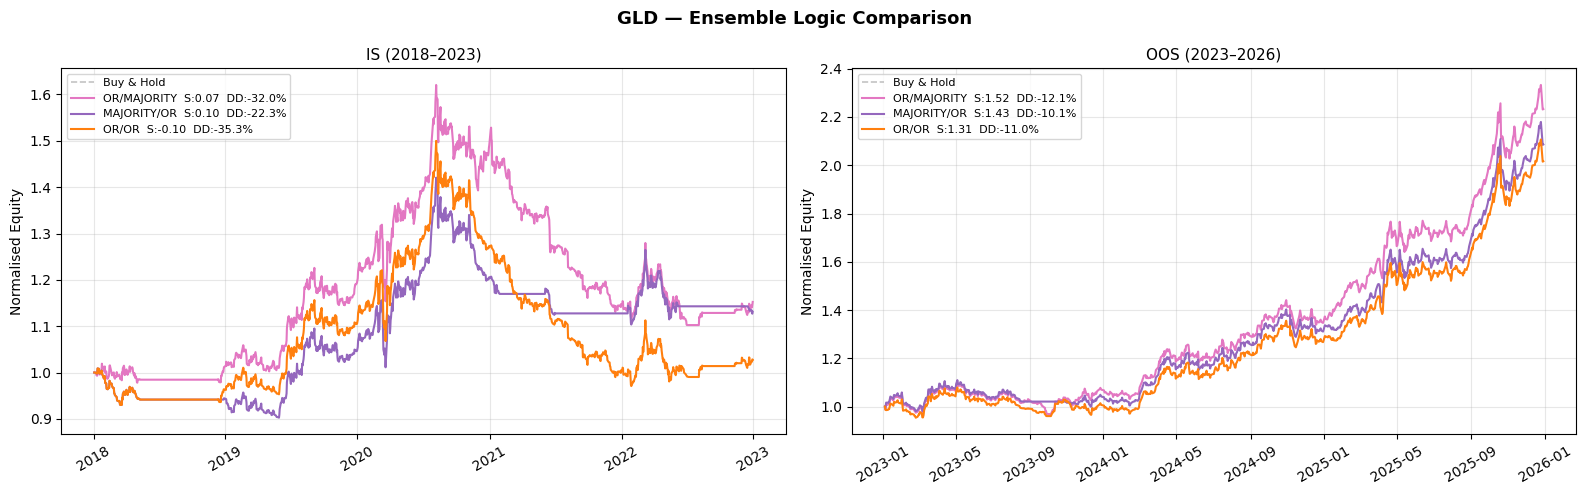

In [33]:
# CELL 9 RUN SINGLE TICKER
# ── Configure ──────────────────────
ticker = 'GLD'   # change to any ticker
top_n  = 4       # combos to show on chart
# ───────────────────────────────────

print(f'Running all 9 combinations for {ticker}...\n')
summary_df, results = run_all_combos(ticker)

if summary_df is not None:
    print(f'═══ {ticker} — All Combinations sorted by OOS Sharpe ═══\n')
    display(summary_df)
    plot_results(ticker, results, top_n=top_n)

In [34]:
# CELL 10 INDIVIDUAL SIGNAL BREAKDOWN

# Shows each indicator solo vs the ensemble for a chosen combo
combo_to_inspect = 'AND/OR'   # change to any row from the table above

if results:
    plot_individual_signals(ticker, results, combo_key=combo_to_inspect)

AND/OR not found — available: ['OR/OR', 'OR/MAJORITY', 'MAJORITY/OR']


In [35]:
# CELL 11 FULL UNIVERSE WITH ONE FIXED COMBO
# ── Configure ──────────────────────
ENTRY = 'AND'
EXIT  = 'OR'
# ───────────────────────────────────

print(f'Full universe | Entry:{ENTRY}  Exit:{EXIT}\n{"─"*70}')

all_rows = []
for t in TICKERS:
    r = run_ticker(t, entry_logic=ENTRY, exit_logic=EXIT, verbose=True)
    if r is None:
        continue
    all_rows.append({
        'Ticker':       t,
        'N Ind':        r['n_indicators'],
        'IS Return':    f"{r['is']['total_return']:.1%}",
        'IS Sharpe':    f"{r['is']['sharpe']:.2f}",
        'IS Max DD':    f"{r['is']['max_dd']:.1%}",
        'IS Trades':    r['is']['trades'],
        'OOS Return':   f"{r['oos']['total_return']:.1%}",
        'OOS Sharpe':   f"{r['oos']['sharpe']:.2f}",
        'OOS Max DD':   f"{r['oos']['max_dd']:.1%}",
        'OOS Trades':   r['oos']['trades'],
        'Sharpe Decay': f"{r['is']['sharpe'] - r['oos']['sharpe']:.2f}",
    })

if all_rows:
    display(pd.DataFrame(all_rows))

Full universe | Entry:AND  Exit:OR
──────────────────────────────────────────────────────────────────────
  GLD | Entry:AND Exit:OR | Full Sharpe:0.99 | IS Sharpe:0.69  OOS Sharpe:1.36 | IS DD:-12.5%  OOS DD:-10.2% | Trades/yr IS:1.6  OOS:1.0  ⚠ FILTERED (< 2 trades/yr)
  SPY | Entry:AND Exit:OR | Full Sharpe:2.20 | IS Sharpe:2.12  OOS Sharpe:2.36 | IS DD:-5.1%  OOS DD:-4.8% | Trades/yr IS:7.0  OOS:7.7
  QQQ | Entry:AND Exit:OR | Full Sharpe:0.79 | IS Sharpe:0.97  OOS Sharpe:0.47 | IS DD:-12.6%  OOS DD:-15.8% | Trades/yr IS:6.6  OOS:9.7
  TQQQ | Entry:AND Exit:OR | Full Sharpe:0.66 | IS Sharpe:0.47  OOS Sharpe:0.99 | IS DD:-47.4%  OOS DD:-32.2% | Trades/yr IS:5.0  OOS:6.0
  BTC-USD | Entry:AND Exit:OR | Full Sharpe:2.94 | IS Sharpe:2.76  OOS Sharpe:3.26 | IS DD:-14.1%  OOS DD:-7.1% | Trades/yr IS:4.6  OOS:8.0
  SOL-USD | Entry:AND Exit:OR | Full Sharpe:2.61 | IS Sharpe:2.94  OOS Sharpe:2.31 | IS DD:-36.3%  OOS DD:-31.7% | Trades/yr IS:4.0  OOS:7.3
  ETH-USD | Entry:AND Exit:OR | Full S

,Ticker,N Ind,IS Return,IS Sharpe,IS Max DD,IS Trades,OOS Return,OOS Sharpe,OOS Max DD,OOS Trades,Sharpe Decay
0,GLD,3,52.7%,0.69,-12.5%,8,102.1%,1.36,-10.2%,3,-0.67
1,SPY,2,176.7%,2.12,-5.1%,35,90.1%,2.36,-4.8%,23,-0.24
2,QQQ,3,89.9%,0.97,-12.6%,33,21.7%,0.47,-15.8%,29,0.50
3,TQQQ,1,94.6%,0.47,-47.4%,25,171.6%,0.99,-32.2%,18,-0.52
4,BTC-USD,2,7582.9%,2.76,-14.1%,23,1778.3%,3.26,-7.1%,24,-0.49
5,SOL-USD,2,98239.3%,2.94,-36.3%,11,3886.3%,2.31,-31.7%,22,0.63
6,ETH-USD,2,17981.0%,2.27,-35.8%,34,451.3%,1.72,-22.0%,20,0.55
7,BNB-USD,3,6345.2%,1.64,-30.0%,72,41.1%,0.52,-25.6%,61,1.12
8,MSFT,2,159.7%,1.02,-14.2%,3,93.4%,1.19,-18.8%,7,-0.17
9,AAPL,3,-3.3%,-0.33,-4.3%,2,3.3%,0.84,-0.1%,2,-1.17


In [36]:
# CELL 12

print('Finding best combination per ticker...\n' + '─'*70)

best_rows = []
for t in TICKERS:
    print(f'  {t}...', end=' ', flush=True)
    _, res = run_all_combos(t)
    if res is None:
        print('skipped')
        continue

    # ── Select on full-period Sharpe, not OOS Sharpe ──
    best_key = max(
        res,
        key=lambda k: res[k]['full']['sharpe']
                      if pd.notna(res[k]['full']['sharpe']) else -99
    )
    r = res[best_key]
    entry, exit_ = best_key.split('/')
    print(f'best={best_key}  Full Sharpe={r["full"]["sharpe"]:.2f}  '
          f'OOS Sharpe={r["oos"]["sharpe"]:.2f}  '
          f'Decay={r["is"]["sharpe"] - r["oos"]["sharpe"]:.2f}')

    best_rows.append({
        'Ticker':        t,
        'N Ind':         r['n_indicators'],
        'Best Entry':    entry,
        'Best Exit':     exit_,
        'Full Sharpe':   f"{r['full']['sharpe']:.2f}",
        'Full Return':   f"{r['full']['total_return']:.1%}",
        'Full Max DD':   f"{r['full']['max_dd']:.1%}",
        'IS Sharpe':     f"{r['is']['sharpe']:.2f}",
        'OOS Sharpe':    f"{r['oos']['sharpe']:.2f}",
        'OOS Max DD':    f"{r['oos']['max_dd']:.1%}",
        'OOS Trades/yr': r['oos']['trades_per_yr'],
        'Sharpe Decay':  f"{r['is']['sharpe'] - r['oos']['sharpe']:.2f}",
    })

if best_rows:
    print('\n═══ Best Combination Per Ticker (by Full-Period Sharpe) ═══\n')
    display(pd.DataFrame(best_rows))

Finding best combination per ticker...
──────────────────────────────────────────────────────────────────────
  GLD...   ⚠  GLD: 6 combo(s) filtered (< 2 trades/yr):
      AND/AND  (IS:0.4 OOS:0.7 trades/yr)
      AND/OR  (IS:1.6 OOS:1.0 trades/yr)
      AND/MAJORITY  (IS:0.6 OOS:0.7 trades/yr)
      OR/AND  (IS:1.4 OOS:0.3 trades/yr)
      MAJORITY/AND  (IS:0.8 OOS:0.3 trades/yr)
      MAJORITY/MAJORITY  (IS:1.2 OOS:0.3 trades/yr)
best=OR/MAJORITY  Full Sharpe=0.70  OOS Sharpe=1.52  Decay=-1.45
  SPY... best=OR/OR  Full Sharpe=2.73  OOS Sharpe=2.87  Decay=-0.22
  QQQ...   ⚠  QQQ: 3 combo(s) filtered (< 2 trades/yr):
      AND/AND  (IS:0.4 OOS:0.7 trades/yr)
      AND/MAJORITY  (IS:1.8 OOS:1.7 trades/yr)
      MAJORITY/AND  (IS:0.8 OOS:1.3 trades/yr)
best=MAJORITY/MAJORITY  Full Sharpe=1.36  OOS Sharpe=1.78  Decay=-0.64
  TQQQ... best=AND/AND  Full Sharpe=0.66  OOS Sharpe=0.99  Decay=-0.52
  BTC-USD... best=AND/OR  Full Sharpe=2.94  OOS Sharpe=3.26  Decay=-0.49
  SOL-USD... best=AND/OR

,Ticker,N Ind,Best Entry,Best Exit,Full Sharpe,Full Return,Full Max DD,IS Sharpe,OOS Sharpe,OOS Max DD,OOS Trades/yr,Sharpe Decay
0,GLD,3,OR,MAJORITY,0.70,161.9%,-32.0%,0.07,1.52,-12.1%,7.7000,-1.45
1,SPY,2,OR,OR,2.73,1108.6%,-5.7%,2.64,2.87,-2.6%,19.8000,-0.22
2,QQQ,3,MAJORITY,MAJORITY,1.36,610.7%,-15.1%,1.14,1.78,-10.9%,3.4000,-0.64
3,TQQQ,1,AND,AND,0.66,428.6%,-50.6%,0.47,0.99,-32.2%,6.0000,-0.52
4,BTC-USD,2,AND,OR,2.94,144211.6%,-14.1%,2.76,3.26,-7.1%,8.0000,-0.49
5,SOL-USD,2,AND,OR,2.61,4423040.3%,-36.3%,2.94,2.31,-31.7%,7.3000,0.63
6,ETH-USD,2,OR,OR,2.21,460983.1%,-41.3%,2.39,1.87,-18.2%,40.0000,0.52
7,BNB-USD,3,MAJORITY,MAJORITY,1.67,136376.0%,-38.3%,1.84,1.37,-27.0%,8.3000,0.47
8,MSFT,2,OR,OR,1.14,551.9%,-26.5%,1.21,1.01,-26.5%,22.1000,0.19
9,AAPL,3,MAJORITY,MAJORITY,1.67,1179.2%,-23.1%,1.74,1.53,-10.1%,9.7000,0.22
